# 08f: Visual Invariance Validation

**Phase 13.6.G Debug Notebook**

## Purpose

Demonstrate DSL correctness through visual validation.

## Visual Pattern

1. **Physics Plot**: Show actual data
2. **Invariance Plot**: Show `method_A - method_B` histogram peaked at 0

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import ROOT
import sys
sys.path.insert(0, '..')

from RDataFrameDSL import DSLCompiler
from tests.generators.toy_nd import generate_nd_2d_root

# Generate test data
print("Generating test data...")
filename = generate_nd_2d_root(size='S', seed=42)
rdf = ROOT.RDataFrame("Events", filename)

# Show what columns actually exist
print(f"Columns in data: {list(rdf.GetColumnNames())}")
print(f"✓ Loaded {rdf.Count().GetValue()} events")

Generating test data...
Columns in data: [b'cluster_Q', b'cluster_x', b'cluster_y', b'event_id', b'event_weight', b'n_tracks', b'track_eta', b'track_pt']
✓ Loaded 10 events
Generated 10 events to /var/folders/qc/qvvq5x6n53v3327fkwnds3cm0000gn/T/toy_nd_2d_xrex3ykd.root


In [12]:
# CORRECT schema - only columns that exist in the data!
# NOTE: track_phi does NOT exist in generate_nd_2d_root output
schema = {
    'event_id': 'long',
    'n_tracks': 'int',
    'event_weight': 'double',
    'track_pt': 'RVec<double>',
    'track_eta': 'RVec<double>',
    # NO track_phi - it doesn't exist!
}

print(f"Schema columns: {list(schema.keys())}")

Schema columns: ['event_id', 'n_tracks', 'event_weight', 'track_pt', 'track_eta']


## Test 1: First dsl.draw() call

✓ First draw() succeeded


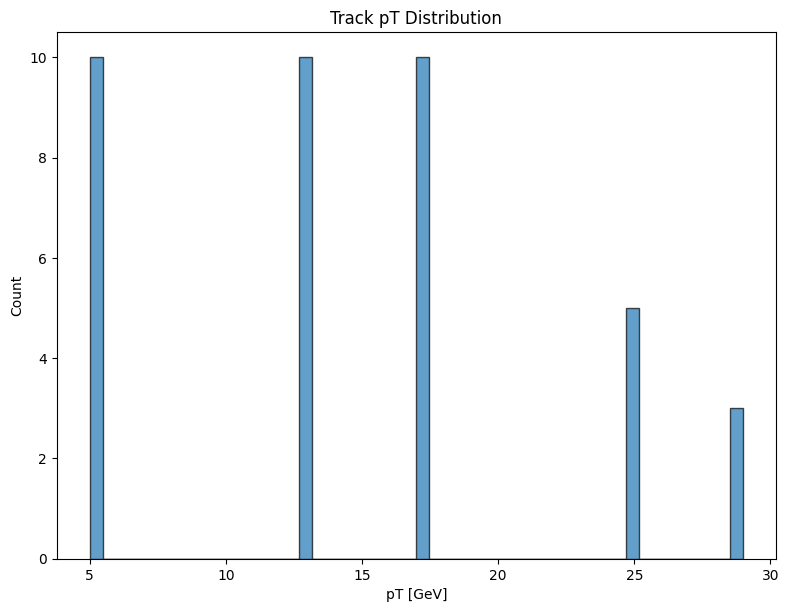

In [13]:
dsl1 = DSLCompiler(schema)
dsl1.define("pt_flat", "track_pt")

fig, ax, stats = dsl1.draw("pt_flat", rdf, bins=50)
ax.set_title("Track pT Distribution")
ax.set_xlabel("pT [GeV]")
print("✓ First draw() succeeded")

## Test 2: Second dsl.draw() call (different DSL instance, same rdf)

✓ Second draw() succeeded


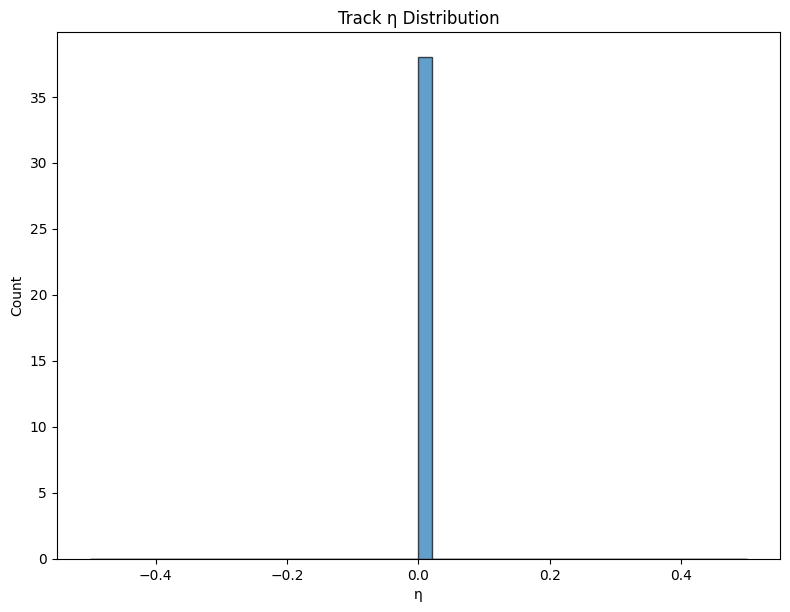

In [14]:
dsl2 = DSLCompiler(schema)
dsl2.define("eta_flat", "track_eta")

fig, ax, stats = dsl2.draw("eta_flat", rdf, bins=50)
ax.set_title("Track η Distribution")
ax.set_xlabel("η")
print("✓ Second draw() succeeded")

## Test 3: Third dsl.draw() - testing robustness

✓ Third draw() succeeded


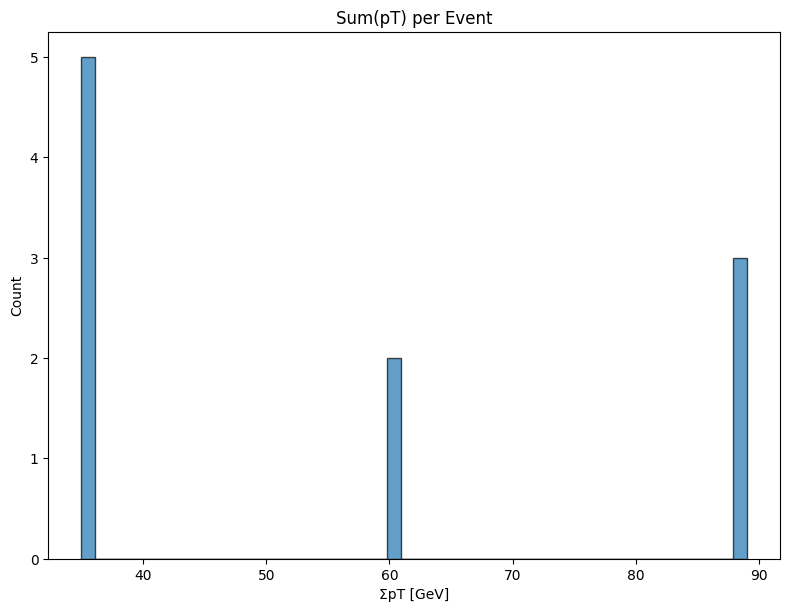

In [15]:
dsl3 = DSLCompiler(schema)
dsl3.define("sum_pt", "Sum(track_pt)")

fig, ax, stats = dsl3.draw("sum_pt", rdf, bins=50)
ax.set_title("Sum(pT) per Event")
ax.set_xlabel("ΣpT [GeV]")
print("✓ Third draw() succeeded")

## Test 4: Invariance test with single DSL instance

In [ ]:
dsl4 = DSLCompiler(schema)

# Define invariance test: Sum(v) == v[0] + Sum(v[1:])
dsl4.define("has_tracks", "n_tracks >= 2")
dsl4.define("sum_A", "Sum(track_pt)")
dsl4.define("sum_B", "track_pt[0] + Sum(track_pt[1:])")
dsl4.define("diff", "sum_A - sum_B")

# Draw the difference - should be 0
fig, ax, stats = dsl4.draw("diff", rdf, bins=50, selection="has_tracks")
ax.set_title("Invariance: Sum(v) - (v[0] + Sum(v[1:]))")
ax.set_xlabel("Difference")
ax.axvline(0, color='red', linestyle='--', linewidth=2)
print("✓ Invariance test succeeded")

In [ ]:
# Numerical verification
df = dsl4.to_pandas(rdf, columns=['diff', 'has_tracks'])
df_filtered = df[df['has_tracks'] == True]
max_diff = np.max(np.abs(df_filtered['diff'].values))
print(f"Max |difference|: {max_diff:.2e}")
print(f"✓ INVARIANCE VERIFIED" if max_diff < 1e-10 else "✗ FAILED")

## Summary

This notebook demonstrates:
1. Multiple `dsl.draw()` calls work sequentially
2. Different DSL instances can share the same RDF
3. Invariance tests show difference peaked at 0

In [ ]:
print("="*60)
print("08f_invariance_visual.ipynb: COMPLETE")
print("="*60)